# Structured Outputs

- Model requested to provide response in format matching a given schema
- useful for downstream processing 


# Pydantic
- rich feature sets with field valdiation, descriptions, nested structures.

In [17]:
import os 
from langchain.chat_models import init_chat_model

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

model = init_chat_model("groq:qwen/qwen3-32b")
model


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x14b459460>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x149702960>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
from pydantic import BaseModel, Field

class Movie(BaseModel):
    title: str = Field(description="Title of the movie")
    year: int = Field(description="Year the movie was released")
    director: str = Field(description='director of the movie')
    rating: float = Field(descrition= 'Movie rating out of 10')



/var/folders/d8/23t4n8194tz6vf0nwp43n6rh0000gn/T/ipykernel_21082/1899206035.py:7: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'descrition'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  rating: float = Field(descrition= 'Movie rating out of 10')


In [10]:
model_with_structure = model.with_structured_output(Movie)
model_with_structure


_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x14b43df40>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x14b44ecc0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Movie', 'description': '', 'parameters': {'properties': {'title': {'description

In [6]:
model.invoke('Provide details of the movie Interstellar')

AIMessage(content='"Interstellar" is a 2014 American science fiction film directed by Christopher Nolan. It\'s an epic, ambitious, and visually stunning exploration of space travel, time dilation, love, and humanity\'s survival.\n\nHere\'s a detailed breakdown of the movie:\n\n**Synopsis:**\n\nIn a near-future Earth ravaged by ecological collapse, dust storms are common, crops are failing, and humanity is facing extinction. Cooper (Matthew McConaughey), a former NASA pilot turned farmer, is struggling to provide for his children, especially his bright and curious daughter, Murph.\n\nWhen a mysterious gravitational anomaly leads them to a secret NASA base, Cooper is presented with a desperate mission: to travel through a newly discovered wormhole near Saturn to find a new habitable planet for humanity. He must leave his family behind, knowing that due to the effects of relativity, time will pass much slower for him than for them.\n\nThe mission, called "Lazarus," involves a small crew v

In [11]:
model_with_structure.invoke('Provide details of the movie Interstellar')

Movie(title='Interstellar', year=2014, director='Christopher Nolan', rating=8.6)

In [ ]:
from pydantic import BaseModel, Field

class Movie(BaseModel):
    title: str = Field(..., description="Title of the movie")
    year: int = Field(..., description="Year the movie was released")
    director: str = Field(..., description='director of the movie')
    rating: float = Field(..., descrition= 'Movie rating out of 10')

model_with_struct2 = model.with_structured_output(Movie, include_raw =True)
# this will include the raw along with the structured output of Movie 

response = model_with_stuct2.invoke('Provide details about Lego')
response 

In [ ]:
from pydantic import BaseModel, Field

class Actor(BaseModel):
    name: str
    role: str

class MovieDetails(BaseModel):
    title: str
    year: int
    cast: list[Actor]
    genres: list[str]
    budget: float | None = Field(None, description='Budget in millions USD')

model_detail_struct = model.with_structured_output(MovieDetails)

response = model_detail_struct.invoke('Provide details about Martian')
response 

# TypedDict

- uses python built-in typing
- used when one does not need runtime validation

In [ ]:
from typing_extensions import TypedDict, Annotated

class MovieDictTD(TypedDict):
    """Details of the movie"""
    title: Annotated[str, ..., "The title of the movie"]
    year: Annotated[int, ..., "Year the movie was released"]
    director: Annotated[str,...,"The director of the movie"]
    rating: Annotated[float, ..., 'Movie rating out of 10']

model_with_struct_td = model.with_structured_output(MovieDictTD)
response = model_with_stuct_td.invoke('Provide details of Hobbits')
response

In [ ]:
from typing_extensions import TypedDict, Annotated

class Actor(TypedDict):
    name: str
    role: str

class MovieDetails(TypedDict):
    title: str
    year: int
    cast: list[Actor]
    genres: list[str]
    budget: float | None = Field(None, description='Budget in millions USD')

model_detail_struct = model.with_structured_output(MovieDetails)

response = model_detail_struct.invoke('Provide details about Martian')
response 

In [16]:
model.profile

{'name': 'Qwen3 32B',
 'release_date': '2024-12-23',
 'last_updated': '2024-12-23',
 'open_weights': True,
 'max_input_tokens': 131072,
 'max_output_tokens': 40960,
 'text_inputs': True,
 'image_inputs': False,
 'audio_inputs': False,
 'video_inputs': False,
 'text_outputs': True,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': True,
 'tool_calling': True,
 'attachment': False,
 'temperature': True}

# DataClasses

created using @dataclass decorator


In [18]:
import os

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

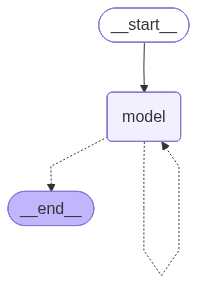

In [19]:
from pydantic import BaseModel, Field 
from langchain.agents import create_agent

class ContactInfo(BaseModel):
    "Person's contact information"
    name: str = Field(description="Name of the person")
    email: str = Field(description="Mail address of the person")
    phone: int = Field(description="Phone number of the person")

agent = create_agent(
    model='groq:qwen/qwen3-32b',
    response_format=ContactInfo
)

agent

In [ ]:
result = agent.invoke({
    'messages': [{
        'role':'user',
        'content': 'Extract contact information from : Jone Doe, joe@example.com, (10) 1234567890'
    }]
})

print(result['structured_response'])

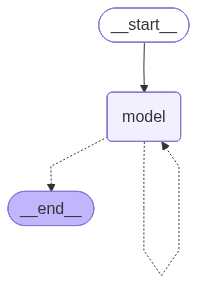

In [21]:
from typing_extensions import TypedDict
from langchain.agents import create_agent

class ContactInfoTD(TypedDict):
    "Person's contact information"
    name: str = "Name of the person"
    email: str = "Mail address of the person"
    phone: int = "Phone number of the person"

agent = create_agent(
    model='groq:qwen/qwen3-32b',
    response_format=ContactInfoTD
)

agent

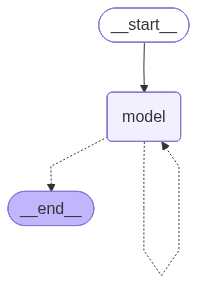

In [22]:
# Dataclass

from dataclasses import dataclass
from langchain.agents import create_agent

@dataclass
class ContactInfoDC:
    """Person's Contact information"""
    name: str
    email: str
    phone: str

agent = create_agent(
    model='groq:qwen/qwen3-32b',
    response_format=ContactInfoDC
)
agent